# 02 — Designing a binary format, byte by byte

This notebook is the walkthrough for `data_engine/binfmt.py` and
`data_engine/replay.py`. By the end you should be able to draw the file layout
on a whiteboard from memory, justify every padding byte, and say honestly what
the format won and what it lost.

The premise: **the tape is written once and read thousands of times.** Every
training epoch, every backtest, every latency benchmark walks it end to end.
So the format is optimised for reading, and specifically for reading *without
parsing* — not "parse faster", but "do not parse at all".

We work on `notebooks/sample_data/btcusdt_sample.tape`, the first 100 blocks of
a real BTCUSDT capture.

**Roadmap**

1. The header, and why it is a fixed 64 bytes.
2. Every byte of both record types.
3. Fixed-point `int64` instead of `float64`.
4. Alignment: what the padding bytes buy.
5. Endianness, decided rather than defaulted.
6. Blocks, and the seek-versus-size tradeoff.
7. Zero-copy reads, demonstrated.
8. A real spread series, straight out of the mapping.
9. The honest size result — which is not the one we hoped for.

## 1. The header

Every file starts with 64 bytes describing what follows. Fixed size, not
length-prefixed and not self-describing.

**Why fixed?** Because it means the first record begins at offset 64 — a
constant known at compile time. `mapping[64:]` is the data, and a reader can
address any record by arithmetic before it has parsed anything at all. A
variable-length header would force a parse step before the first byte of data
could be located, which is precisely the class of work this format exists to
delete.

The trailing 24 reserved bytes are not waste. They are the room a future
version needs to add a field without moving anything that already exists — the
difference between a format that can evolve and one that needs a v2 reader.

In [1]:
import json
import sys
from pathlib import Path

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "data_engine").exists():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from data_engine.binfmt import (
    EVENT_DTYPE, HEADER_SIZE, block_dtype, bytes_per_event, snapshot_dtype,
)
from data_engine.replay import TapeReader, snapshot_mid_prices, snapshot_spreads

TAPE = REPO_ROOT / "notebooks" / "sample_data" / "btcusdt_sample.tape"
reader = TapeReader(TAPE)
header = reader.header
print(f"file        : {TAPE.name} ({TAPE.stat().st_size:,} bytes)")
print(f"symbol      : {header.symbol}   version: {header.version}")
print(f"price scale : {header.price_scale:,}   qty scale: {header.qty_scale:,}")
print(f"snapshot every {header.snapshot_interval} events, {header.depth_levels} levels per side")
print(f"blocks      : {reader.block_count}")

file        : btcusdt_sample.tape (434,464 bytes)
symbol      : BTCUSDT   version: 1
price scale : 100,000,000   qty scale: 100,000,000
snapshot every 100 events, 10 levels per side
blocks      : 100


### What the header told us

Everything a reader needs to interpret the rest of the file, and nothing it
does not. Note `price_scale`: the file *records* that prices are stored as
`price x 10^8` rather than assuming it. If we ever capture an instrument on a
different grid, old tapes stay readable, because each one carries its own
scale.

`snapshot_interval` and `depth_levels` are the two numbers that determine the
block geometry, which is why they live in the header rather than in a constant
somewhere in the reader.

## 2. Every byte of the layout

### File header — 64 bytes

| Offset | Size | Field | Type | Why it is there |
|---|---|---|---|---|
| 0 | 4 | `magic` | `b'TTS1'` | Is this our file at all? Checked before anything else |
| 4 | 2 | `version` | `u16` | Refuse a file written by a newer writer |
| 6 | 2 | *padding* | — | Pushes `symbol` to offset 8 |
| 8 | 8 | `symbol` | `char[8]` | `BTCUSDT`, ASCII, zero-padded |
| 16 | 4 | `price_scale` | `u32` | 100000000 |
| 20 | 4 | `qty_scale` | `u32` | 100000000 |
| 24 | 8 | `capture_start_ns` | `u64` | Wall clock at session start |
| 32 | 4 | `snapshot_interval` | `u32` | Events per block |
| 36 | 4 | `depth_levels` | `u32` | Ladder depth in a snapshot |
| 40 | 24 | *reserved* | — | Room to grow without breaking old readers |

### Event record — 40 bytes

| Offset | Size | Field | Type | Notes |
|---|---|---|---|---|
| 0 | 1 | `kind` | `u8` | Always 2 (`KIND_EVENT`) — the record-type tag |
| 1 | 1 | `event_type` | `u8` | 0 diff, 1 trade, 2 padding |
| 2 | 1 | `side` | `u8` | 0 bid, 1 ask, 2 n/a |
| 3 | 5 | *padding* | — | **Pushes the first `int64` to offset 8** |
| 8 | 8 | `local_ts_ns` | `u64` | Our receive clock |
| 16 | 8 | `exchange_ts_ns` | `u64` | The venue's clock |
| 24 | 8 | `price` | `i64` | Fixed point |
| 32 | 8 | `qty` | `i64` | Fixed point; 0 means the level was deleted |

### Snapshot record — 344 bytes

| Offset | Size | Field | Type | Notes |
|---|---|---|---|---|
| 0 | 1 | `kind` | `u8` | Always 1 (`KIND_SNAPSHOT`) |
| 1 | 7 | *padding* | — | Pushes the first `int64` to offset 8 |
| 8 | 8 | `local_ts_ns` | `u64` | |
| 16 | 8 | `exchange_ts_ns` | `u64` | |
| 24 | 160 | `bids` | `i64[10][2]` | `[price, qty]`, best first, descending |
| 184 | 160 | `asks` | `i64[10][2]` | `[price, qty]`, best first, ascending |

A level of `[0, 0]` means "this side had fewer than 10 levels". That is
unambiguous rather than merely conventional: a real level always has a
strictly positive price, which `OrderBook.assert_valid` enforces.

In [2]:
raw_header = TAPE.read_bytes()[:HEADER_SIZE]
for row_start in range(0, HEADER_SIZE, 16):
    chunk = raw_header[row_start:row_start + 16]
    hex_bytes = " ".join(f"{byte:02x}" for byte in chunk)
    printable = "".join(chr(b) if 32 <= b < 127 else "." for b in chunk)
    print(f"{row_start:04x}  {hex_bytes:<47}  |{printable}|")

0000  54 54 53 31 01 00 00 00 42 54 43 55 53 44 54 00  |TTS1....BTCUSDT.|
0010  00 e1 f5 05 00 e1 f5 05 c4 42 91 ae c1 31 c6 18  |.........B...1..|
0020  64 00 00 00 0a 00 00 00 00 00 00 00 00 00 00 00  |d...............|
0030  00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00  |................|


### Reading the hex by eye

Row `0000` starts with `54 54 53 31` — `TTS1`, the magic, visible in the ASCII
column on the right. Then `01 00`, version 1 as a little-endian `u16`. Two
zero bytes of padding, then `42 54 43 55 53 44 54 00` — `BTCUSDT` and one zero
byte of the 8-byte symbol field.

Row `0010` holds the two scales: `00 e1 f5 05` is `0x05f5e100` = 100,000,000,
read back-to-front because the file is little-endian. Then the capture start
timestamp. Row `0020` is `64 00 00 00` (interval 100) and `0a 00 00 00`
(10 levels), and everything after is the reserved span, all zeros.

That is the entire header, and you can verify it with your eyes. This is what
"explain every byte" means in practice, and it is why a hand-rolled format is
worth building once even though Parquet exists.

## 3. Why fixed-point `int64` and never `float64`

Prices live on a tick grid. Storing them as scaled integers rather than floats
buys three things that all matter here:

1. **Exactness.** `0.29` has no exact binary float representation. On the tick
   grid, `29000000` is just an integer.
2. **Comparability.** Level identity is dictionary-key identity. Two floats
   that *should* be the same level can differ in the last bit and become two
   levels — a bug that is invisible for hours. Integers cannot do this.
3. **Sortability and arithmetic.** Spreads, mids and imbalances become integer
   arithmetic with no accumulated rounding.

The cost: we must carry the scale, and we must refuse data finer than the grid
rather than silently truncating it. Both are in the header and in `to_fixed`.

In [3]:
snapshots = reader.load_snapshots()
best_bid = int(snapshots["bids"][0, 0, 0])
best_ask = int(snapshots["asks"][0, 0, 0])

print(f"stored best bid : {best_bid:,}  ->  {best_bid / header.price_scale:,.2f}")
print(f"stored best ask : {best_ask:,}  ->  {best_ask / header.price_scale:,.2f}")
print(f"spread in ticks : {best_ask - best_bid}  (exact integer subtraction)")

# The same arithmetic through float64, which is what we chose not to do.
float_bid, float_ask = best_bid / 1e8, best_ask / 1e8
print(f"\nvia float64     : {float_ask - float_bid!r}")
print(f"is that 0.01?   : {float_ask - float_bid == 0.01}")

stored best bid : 6,454,999,000,000  ->  64,549.99
stored best ask : 6,455,000,000,000  ->  64,550.00
spread in ticks : 1000000  (exact integer subtraction)

via float64     : 0.010000000002037268
is that 0.01?   : False


### The point, in one line of output

The integer subtraction gives exactly `1000000` ticks — one cent, on the nose.
The float subtraction gives `0.010000000002037268`, which is not a cent, does
not compare equal to `0.01`, and carries error that only grows as it flows
through further arithmetic.

Now imagine that as a dictionary key, or as a threshold test in a trading rule,
or as a label boundary in Stage 3. Every one of those is a place where "almost
equal" silently becomes "not equal", and the resulting bug produces plausible
numbers rather than an error. Integers remove the entire class of problem.

## 4. Alignment — what those padding bytes buy

The event record needs 36 bytes of actual payload. We spend 40.

The four extra bytes exist so that every `int64` starts at an offset divisible
by 8. That matters for one concrete reason: **numpy can only describe a
strided view over memory if the fields land where the dtype says they do.**
Put the record-type tag as a loose byte *between* records instead of inside
them, and records start at offsets 1, 42, 83 — every `int64` on an odd
address, no view possible, and the whole zero-copy design collapses back into
a parse loop.

This is also why the tag is byte 0 *of* each record rather than a byte before
it. Same one byte, same "tag precedes payload" property, but it rides inside
the aligned frame instead of destroying it.

In [4]:
for name, dtype in (("event", EVENT_DTYPE), ("snapshot", snapshot_dtype(header.depth_levels))):
    print(f"{name} record, itemsize {dtype.itemsize}:")
    for field in dtype.names:
        field_dtype, offset = dtype.fields[field][0], dtype.fields[field][1]
        base = field_dtype.base
        flag = ""
        if base.itemsize == 8 and base.kind in "iu":
            flag = "  <- 8-byte field, aligned" if offset % 8 == 0 else "  <- MISALIGNED"
        print(f"   +{offset:<4} {field:<16} {str(field_dtype):<12}{flag}")
    print()

event record, itemsize 40:
   +0    kind             uint8       
   +1    event_type       uint8       
   +2    side             uint8       
   +3    padding          |V5         
   +8    local_ts_ns      uint64        <- 8-byte field, aligned
   +16   exchange_ts_ns   uint64        <- 8-byte field, aligned
   +24   price            int64         <- 8-byte field, aligned
   +32   qty              int64         <- 8-byte field, aligned

snapshot record, itemsize 344:
   +0    kind             uint8       
   +1    padding          |V7         
   +8    local_ts_ns      uint64        <- 8-byte field, aligned
   +16   exchange_ts_ns   uint64        <- 8-byte field, aligned
   +24   bids             ('<i8', (10, 2))  <- 8-byte field, aligned
   +184  asks             ('<i8', (10, 2))  <- 8-byte field, aligned



### Every 8-byte field on an 8-byte boundary

`local_ts_ns` at 8, `exchange_ts_ns` at 16, `price` at 24, `qty` at 32. The
padding at offsets 3 and 1 is doing exactly one job, and it is doing it.

There is a test that asserts this rather than trusting the offsets were typed
correctly — `test_every_int64_field_is_eight_byte_aligned`. Layout constants
are the kind of thing that is right when written and wrong after the third
edit.

The block size inherits the property: `344 + 40N` is a multiple of 8 for any
`N`, so no block can knock the next one off a boundary.

## 5. Endianness, decided rather than defaulted

Every multi-byte field is declared little-endian (`<u8`, `<i8`), not
"native".

The traditional choice for anything serialised is big-endian, "network byte
order". We rejected it: every machine this will ever run on — x86-64 and
ARM64 — is little-endian, so big-endian would mean a byte swap on every field
on every read, buying portability to hardware that is not in our deployment
and never will be.

Declaring `<` rather than leaving it native is the important part. "Native"
would mean a tape written on one machine could be misread on another, and the
symptom would be absurd prices rather than an error.

In [5]:
value = int(snapshots["local_ts_ns"][0])
as_little = value.to_bytes(8, "little")
as_big = value.to_bytes(8, "big")
print(f"timestamp        : {value:,}")
print(f"little-endian    : {as_little.hex(' ')}   <- what is on disk")
print(f"big-endian       : {as_big.hex(' ')}")
print(f"misread as big   : {int.from_bytes(as_little, 'big'):,}")

timestamp        : 1,785,169,010,226,979,000
little-endian    : b8 60 9d ae c1 31 c6 18   <- what is on disk
big-endian       : 18 c6 31 c1 ae 9d 60 b8
misread as big   : 13,285,792,274,634,098,200


### Why this is not a theoretical concern

Reading the same eight bytes with the wrong endianness turns a 2026 timestamp
into a number around 10^19. It does not raise; it just produces a
wildly wrong value that then flows into every downstream feature.

That is the recurring theme of this format: the failure modes of a binary
layout are all *silent*. Which is why the decisions get declared explicitly
and then asserted in tests, instead of being left to whatever the platform
happens to do.

## 6. Blocks, and the seek-versus-size tradeoff

The file is not a free mixture of records. It is:

```
[64-byte header][block 0][block 1][block 2]...

  each block = [ 1 snapshot, 344 B ][ N events, 40 B each ]
```

always, with the final block padded out with explicitly tagged filler so that
**every file is exactly `header + M * block_size` bytes**.

That rigidity is what buys the two properties the reader depends on:

- **O(1) seek.** Block `k` starts at `64 + k * block_size`. No index, no scan.
- **A single zero-copy view.** A numpy view needs a constant stride. Blocks
  give it one.

The snapshot interval `N` is the dial:

| `N` | Snapshot overhead | Worst-case events to replay after a seek |
|---|---|---|
| 10 | 34.4 B/event (86%) | 10 |
| 100 | 3.44 B/event (8.6%) | 100 |
| 1000 | 0.34 B/event (0.9%) | 1000 |

Small `N` means fast seeks and a fat file; large `N` means a lean file and
more replay work per seek. We chose 100: under 9% overhead, and replaying 100
events costs microseconds.

In [6]:
block = block_dtype(header.snapshot_interval, header.depth_levels)
snapshot_bytes = snapshot_dtype(header.depth_levels).itemsize
payload_bytes = TAPE.stat().st_size - HEADER_SIZE

print(f"block size      : {snapshot_bytes} + {header.snapshot_interval} x {EVENT_DTYPE.itemsize} "
      f"= {block.itemsize:,} bytes")
print(f"payload bytes   : {payload_bytes:,}")
print(f"divides exactly : {payload_bytes % block.itemsize == 0}  "
      f"({payload_bytes // block.itemsize} blocks)")
print(f"amortised cost  : {bytes_per_event(header):.2f} bytes per event")

target = 7
print(f"\nblock {target} starts at byte {HEADER_SIZE + target * block.itemsize:,} - pure arithmetic, no scan")
print(f"seek by time    : block {reader.block_index_for_timestamp(int(snapshots['local_ts_ns'][target]))}")

block size      : 344 + 100 x 40 = 4,344 bytes
payload bytes   : 434,400
divides exactly : True  (100 blocks)
amortised cost  : 43.44 bytes per event

block 7 starts at byte 30,472 - pure arithmetic, no scan
seek by time    : block 7


### The invariant, checked

The payload divides exactly into 100 blocks. That single property is what lets
the reader map the file in one view and trust the arithmetic — and it is why
the writer pads the final block on close rather than leaving a ragged tail.

It also means **the file can be truncated at any block boundary and stays
completely valid**. This very sample was made that way: it is the first 100
blocks of a 1,073-block capture, cut with a byte slice and nothing else.

A tape cut anywhere *else* is not silently accepted — the reader logs a
warning and reads the whole blocks, which is the right behaviour when a capture
process is killed mid-write.

## 7. Zero-copy, demonstrated rather than asserted

`load_snapshots()` returns every snapshot in the file as a numpy structured
array. The claim is that this involves no copying and no parsing at all: the
array is a window onto the memory-mapped pages.

Two ways to check. `owndata` tells us whether the array allocated its own
buffer, and `base` tells us what it is a view *of*. And the timing tells us
whether anything proportional to file size happened.

In [7]:
import time

started = time.perf_counter()
snaps = reader.load_snapshots()
elapsed = time.perf_counter() - started

print(f"snapshots       : {snaps.shape}, dtype itemsize {snaps.dtype.itemsize}")
print(f"owns its data   : {snaps.flags.owndata}   <- False means it is a view")
print(f"base object     : {type(snaps.base).__name__}")
print(f"bytes described : {snaps.nbytes:,}")
print(f"time to 'load'  : {elapsed * 1e6:.1f} microseconds")

bids = snaps["bids"]
print(f"\nfield access is also a view : owndata={bids.flags.owndata}, shape={bids.shape}")

snapshots       : (100,), dtype itemsize 344
owns its data   : False   <- False means it is a view
base object     : ndarray
bytes described : 34,400
time to 'load'  : 30.5 microseconds

field access is also a view : owndata=False, shape=(100, 10, 2)


### 34,400 bytes described in microseconds

`owndata=False` and a non-`None` `base` mean no buffer was allocated. The time
is microseconds regardless of how big the tape is, because nothing
proportional to the file happened — no read, no decode, no allocation. The OS
pages the data in lazily when we actually touch it.

Field access is a view too, which is the property that makes the block layout
pay: `blocks["snapshot"]` extracts one 344-byte record out of every 4,344-byte
block by *striding*, not by gathering.

The honest cost: these arrays are windows onto a mapping, so holding one keeps
that mapping alive. `TapeReader.close()` deliberately does not close the
mapping, because doing so would raise while any view is alive and would force
callers to `del` their arrays — a trap rather than an API.

## 8. A real spread series, straight out of the mapping

Everything above pays off here. Extracting a spread time series is now three
array operations on mapped memory — no loop, no parse, no book reconstruction.

`snapshot_spreads` returns NaN where a side was empty rather than a zero or a
negative number, because an absent quote is not a zero spread and a plot
should show a hole where there was no market.

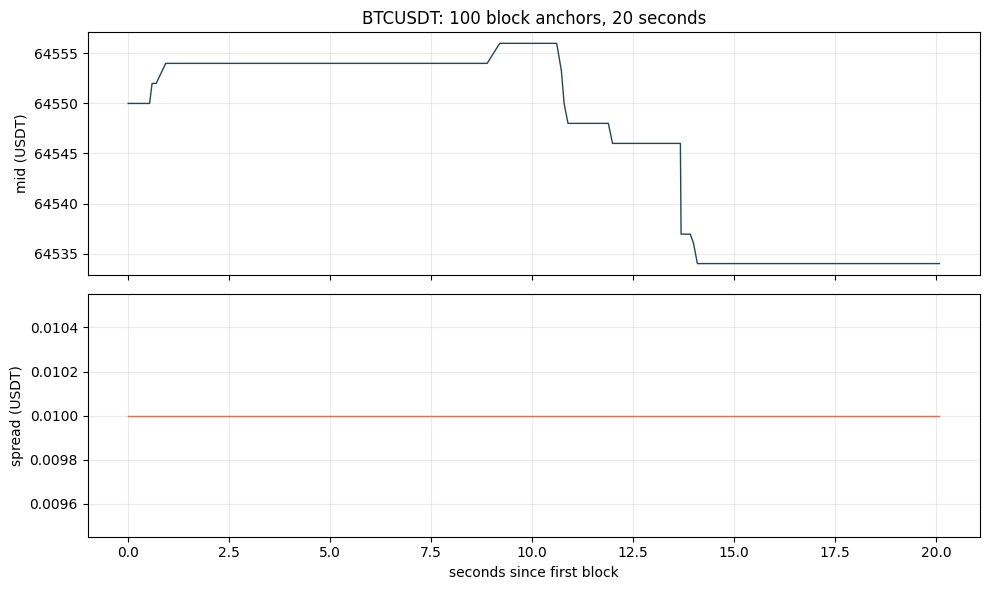

spread: min 0.01  median 0.01  max 0.01
mid   : 64,534.00 -> 64,556.00


In [8]:
spreads = snapshot_spreads(snaps, header.price_scale)
mids = snapshot_mid_prices(snaps, header.price_scale)
elapsed_ns = (snaps["local_ts_ns"] - snaps["local_ts_ns"][0]) / 1e9

figure, (top, bottom) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
top.plot(elapsed_ns, mids, linewidth=1.0, color="#264653")
top.set_ylabel("mid (USDT)")
top.set_title(f"{header.symbol}: {len(snaps)} block anchors, {elapsed_ns[-1]:.0f} seconds")
top.grid(alpha=0.25)

bottom.step(elapsed_ns, spreads, where="post", linewidth=1.0, color="#e76f51")
bottom.set_ylabel("spread (USDT)")
bottom.set_xlabel("seconds since first block")
bottom.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print(f"spread: min {np.nanmin(spreads):.2f}  median {np.nanmedian(spreads):.2f}  max {np.nanmax(spreads):.2f}")
print(f"mid   : {np.nanmin(mids):,.2f} -> {np.nanmax(mids):,.2f}")

### What the series shows

The mid wanders over a 22 USDT range, and the spread is **one cent at every
single one of the 100 anchors** — min, median and max all 0.01. It is a flat
line, and that is the finding, not a rendering problem.

On a mid near 64,550 one basis point is $6.46, so a one-cent spread is
**0.0015 basis points**. BTCUSDT is
one of the tightest markets in existence, and at this timescale the spread is
effectively a constant: the tick size *is* the spread.

Keep that number. Stage 5 asks whether the model's edge exceeds *half* the
spread plus fees, and this plot is the left-hand side of that comparison. A
signal predicting a move smaller than one cent is not a signal, it is a
rounding error with a p-value.

It also has a direct consequence for Stage 3's labels: if the spread never
moves, then spread carries no information here and the predictive content has
to live in *depth and flow* — the sizes resting at each level and the trades
consuming them — not in the width of the quote.

## 9. The honest size result

Here is where the notebook has to report something uncomfortable. The
implementation plan predicted a 10–20x size win over raw JSON. The measured
result is nothing like that.

The numbers below come from `benchmarks/bench_binfmt.py`, run on a capture
session that produced both artefacts from the same market data. They are read
from the saved JSON, not retyped.

In [9]:
import glob

results_path = sorted(glob.glob(str(REPO_ROOT / "benchmarks" / "binfmt_*.json")))[-1]
results = json.loads(Path(results_path).read_text(encoding="utf-8"))

print(f"from {Path(results_path).name}\n")
for name, value in results["sizes"].items():
    print(f"  {name:20s} {value:>12,} bytes")
print()
for name, value in results["bytes_per_event"].items():
    print(f"  {name:20s} {value:>12.1f} bytes/event")
print()
ratios = results["size_ratios"]
print(f"  binary vs raw JSON     : {ratios['binary_vs_json_plain']:.2f}x SMALLER")
print(f"  binary vs gzipped JSON : {1 / ratios['binary_vs_json_gzip']:.2f}x LARGER")
print(f"  both gzipped           : {1 / ratios['binary_gzip_vs_json_gzip']:.2f}x larger")

from binfmt_20260727T162516Z.json

  json_gzip_bytes           710,446 bytes
  json_plain_bytes        7,321,739 bytes
  tape_bytes              4,661,176 bytes
  tape_gzip_bytes           798,022 bytes

  binary                       43.5 bytes/event
  binary_gzip                   7.4 bytes/event
  json_plain                   68.3 bytes/event
  json_gzip                     6.6 bytes/event

  binary vs raw JSON     : 1.57x SMALLER
  binary vs gzipped JSON : 6.56x LARGER
  both gzipped           : 1.12x larger


### 1.57x, not 10x — and gzipped JSON beats us outright

Two reasons, both worth being able to state.

**We store 16 bytes of timestamp on every level record.** One `depthUpdate`
frame carries ~39 changed levels that all share one pair of timestamps. JSON
writes that pair once per frame; our fixed-width format writes it 39 times.
That redundancy is 40% of every event record, and it is the direct price of
the fixed-width design — the same rigidity that buys O(1) addressing.

**JSON of decimal strings gzips extraordinarily well.** Repeated keys,
repeated price prefixes, and a narrow character set are exactly what a
dictionary compressor eats. A 10x ratio on *uncompressed* JSON was never the
right comparison, because gzip costs one line of code and is available to both
formats.

**So did the format fail?** No — but the win is not where the plan said it
would be. Run the throughput cell next.

In [10]:
timings = results["timings"]
for label, timing in timings.items():
    rate = timing["median_units_per_second"]
    print(f"  {label:32s} {timing['median_seconds']:7.3f}s   {rate:>14,.0f} {timing['unit_name']}/s")

speedups = results["speedups"]
print(f"\n  sequential replay : {speedups['sequential_binary_vs_json']:.1f}x faster")
print(f"  vectorised scan   : {speedups['vectorised_binary_vs_json_replay']:.0f}x faster")

  binary sequential replay           0.054s        2,009,049 records/s
  json sequential replay             0.262s          410,441 records/s
  binary vectorised spreads          0.001s          783,956 snapshots/s
  json replay to same spreads        0.358s            2,741 snapshots/s

  sequential replay : 4.9x faster
  vectorised scan   : 261x faster


### The real win is read throughput

Sequential replay is ~5x faster, and that is the *pessimistic* comparison:
both paths are Python loops, so both are dominated by interpreter overhead
rather than by the format.

The vectorised path is ~260x faster, and that gap is the actual thesis. To get
a spread series out of JSON you must parse every frame and rebuild the book,
because JSON has no addressable structure. To get it out of the tape you take
a strided view and subtract two columns. One is proportional to the data; the
other is proportional to the answer.

**The honest summary for a README:** this format trades disk space for access
time. It is 1.57x smaller than raw JSON, 6.6x *larger* than gzipped JSON, and
between 5x and 260x faster to read depending on the access pattern. For a tape
written once and read every training epoch, that is the right trade — and if
disk ever became the binding constraint, the fix is known and specific: hoist
the shared timestamps into a per-frame header record and shrink the event
record to 24 bytes.

In [11]:
reader.close()
print("reader closed; the arrays above stay valid because they hold the mapping alive")
print(f"spread series still readable: {np.nanmedian(spreads):.2f} USDT median")

reader closed; the arrays above stay valid because they hold the mapping alive
spread series still readable: 0.01 USDT median


## Interview checkpoint

**1. Why a fixed 64-byte header instead of a length-prefixed or self-describing one?**
A fixed size means the first record is at a compile-time-known offset, so a
reader can address any record by arithmetic before parsing anything — with a
variable header you must parse before you can even locate the data, which is
the exact work this format exists to eliminate. The 24 reserved bytes let a
future version add fields without moving existing ones, so old readers keep
working. The cost is a hard 8-byte cap on the symbol field, which is checked
and raises rather than truncating.

**2. Why is the record-type tag byte 0 of the record rather than a byte before it?**
Because a loose byte between records shifts everything after it: 40-byte
records would start at offsets 1, 42, 83, putting every `int64` on an odd
address. numpy cannot describe that with a strided view, so `load_snapshots`
would degrade from a zero-copy window into a per-record gather, and on some
architectures misaligned 8-byte loads fault outright. Putting the tag inside
the record's aligned prefix keeps the "tag precedes payload" property at zero
cost.

**3. What does the block structure buy, and what does it cost?**
It buys O(1) seek — block `k` is at `64 + k * block_size`, no index and no
scan — and a constant stride, which is the precondition for a single
zero-copy numpy view over every snapshot in the file. It costs at most `N-1`
padding records per file (about 4 KB) and the rigidity that the writer must
never drift off cadence, which is why `BinaryWriter` refuses an event when a
snapshot is due rather than trusting the caller. The snapshot interval is the
dial: `N=10` gives fast seeks and 86% overhead, `N=1000` gives 0.9% overhead
and up to 1,000 events of replay per seek; we chose 100.

**4. Your format is 6.6x larger than gzipped JSON. Why keep it?**
Because size was the wrong objective for this artefact. The tape is written
once and read every training epoch, so access time dominates, and the measured
read speedup is 5x sequentially and ~260x for the vectorised access pattern
that Stage 3 actually uses. The size result is explainable rather than
mysterious: we write 16 bytes of timestamp per level record where JSON writes
one pair per frame of ~39 levels, and if disk became binding the specific fix
is a per-frame header record dropping the event to 24 bytes.

**5. How do you know the format round-trips correctly?**
Four tests the constitution names as mandatory for this stage: a header
round-trip, a 100,000-record write-then-read demanding every field
byte-identical, a seek-correctness test asserting that `seek + replay`
produces an *identical* book to a full replay, and a corrupted-magic file
raising cleanly rather than returning garbage. The seek test is only possible
because of a design choice — every block re-anchors the book from its own
snapshot, so state at a record cannot depend on how you arrived at it.